<a href="https://colab.research.google.com/github/S-idd/GENAINPTEL/blob/main/PE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

Load Data Set

In [34]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = [
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

print("Training Data Set Shape : ",x_train.shape)
print("Training Data Set Labels : ",y_train.shape)
print("Testing Data Set Shape : ",x_test.shape)
print("Testing Data Set Labels : ",y_test.shape)

Training Data Set Shape :  (50000, 32, 32, 3)
Training Data Set Labels :  (50000, 1)
Testing Data Set Shape :  (10000, 32, 32, 3)
Testing Data Set Labels :  (10000, 1)


Display Images

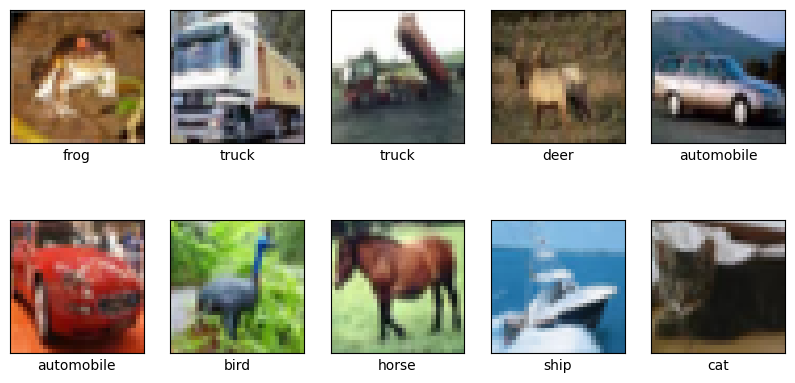

In [35]:
plt.figure(figsize=(10,5))

for i in range (10) :
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

Build An CNN Model

In [36]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10,activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [38]:
history = model.fit (
    x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=64,validation_split=0.2,verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 99ms/step - accuracy: 0.3868 - loss: 1.6630 - val_accuracy: 0.5237 - val_loss: 1.3020
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.5279 - loss: 1.3233 - val_accuracy: 0.6053 - val_loss: 1.1159
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.5917 - loss: 1.1628 - val_accuracy: 0.6399 - val_loss: 1.0229
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 95ms/step - accuracy: 0.6335 - loss: 1.0543 - val_accuracy: 0.6743 - val_loss: 0.9412
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.6635 - loss: 0.9691 - val_accuracy: 0.6767 - val_loss: 0.9313
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6879 - loss: 0.9010 - val_accuracy: 0.7032 - val_loss: 0.8608
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.7050 - loss: 0.8477 - val_accuracy: 0.7055 - val_loss: 0.8584
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.7254 - loss: 0.7950 - 

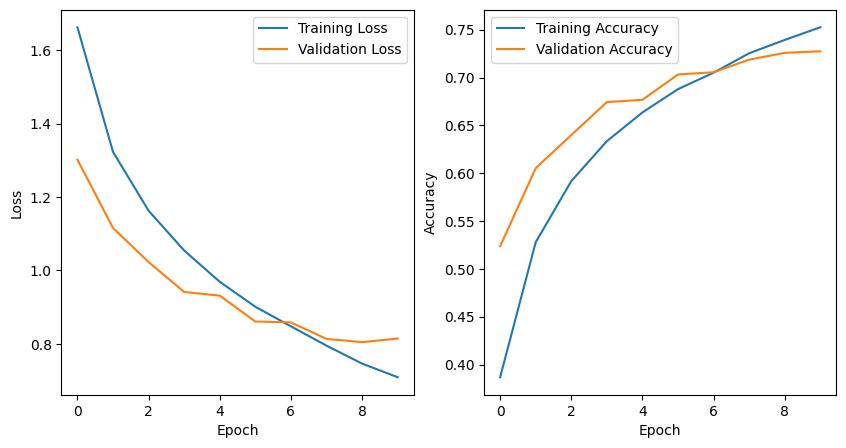

In [39]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Evaluate On Test Data

In [40]:
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=1)
print("Test Loss : ",test_loss)
print("Test Accuracy : ",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7274 - loss: 0.8143
Test Loss :  0.8143154978752136
Test Accuracy :  0.727400004863739


Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


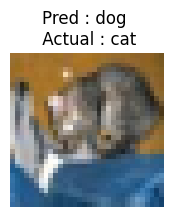

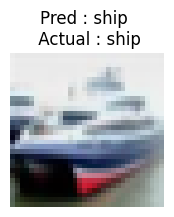

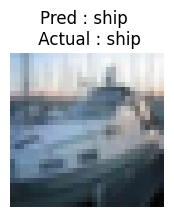

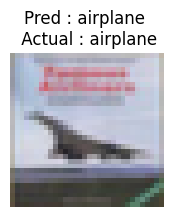

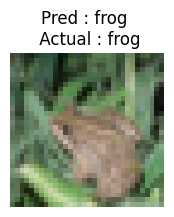

In [41]:
predictions = model.predict(x_test)

for i in range (5):
    prediction_label = np.argmax(predictions[i])
    actual_label = y_test[i][0]

    plt.figure(figsize=(2,2))
    plt.imshow(x_test[i])
    plt.title(f"Pred : {class_names[prediction_label]} \n Actual : {class_names[actual_label]}")
    plt.axis('off')
    plt.show()


Confusion Matrix

<Figure size 1000x800 with 0 Axes>

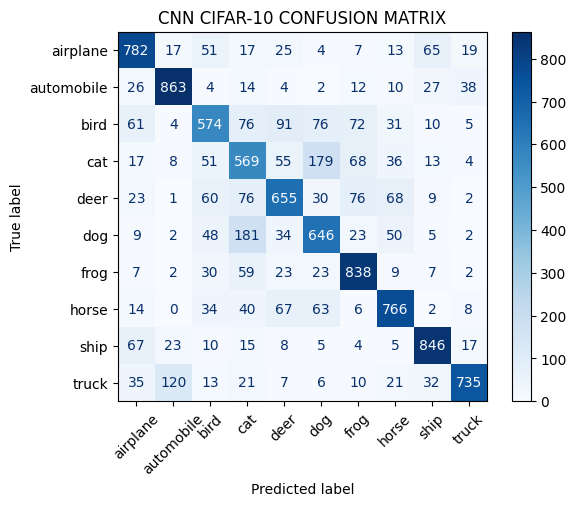

In [42]:
y_pred = np.argmax(predictions,axis=1)

y_true = y_test

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)

disp.plot(cmap=plt.cm.Blues,xticks_rotation=45)

plt.title("CNN CIFAR-10 CONFUSION MATRIX")

plt.show()